## SafeDerm — 07. Champion Model

CNN + Transformer hybrid (ADR-002): a ResNet-50 backbone through its last conv block, feeding a Transformer encoder over the resulting 7x7 spatial grid instead of average-pooling straight into a linear layer like `06_baseline_model.ipynb`'s plain ResNet-50 does. Architecture and rationale live in `src/model.py`'s `ChampionModel` docstring; the specific hyperparameters chosen here are in `docs/decisions/ADR-006-training-recipe-and-champion-model.md`.

Trained with the exact same recipe as the (updated) baseline -- same `src/engine.py` functions, same warmup-then-discriminative-LR-then-early-stopping structure -- so any difference in the results below reflects the architecture change, not a difference in how each model was trained or measured.

### Reproducibility

Same seed as the baseline (`42`) -- not because it needs to match, but so any difference between the two notebooks' results isn't attributable to different random initialization.

In [1]:
import json
import logging

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader

from src.config import (
    IMAGES_DIR, TRAIN_SPLIT_PATH, VAL_SPLIT_PATH, MODELS_DIR,
    CHAMPION_MODEL_PATH, BASELINE_METRICS_PATH, CHAMPION_METRICS_PATH,
)
from src.dataset import SkinLesionDataset, CLASS_TO_IDX
from src.transforms import get_train_transforms, get_eval_transforms
from src.model import build_champion_model
from src.engine import (
    set_seed, compute_class_weights, train_one_epoch, evaluate, malignant_recall,
    get_param_groups, freeze_backbone, unfreeze_all, EarlyStopper, fit,
)
from src.labels import ALL_CLASSES, MALIGNANT_CLASSES

logging.basicConfig(level=logging.INFO, format="%(message)s")
set_seed(42)

BATCH_SIZE = 32
WARMUP_EPOCHS = 2
MAX_EPOCHS = 30
HEAD_LR = 1e-3
BACKBONE_LR = 1e-5
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Rebuild the pipeline

Identical `Dataset`/`DataLoader` setup to `05_pipeline.ipynb`/`06_baseline_model.ipynb` -- same transforms, same batch size, same split files. The only thing that changes between baseline and champion is the model architecture.

In [2]:
train_dataset = SkinLesionDataset(TRAIN_SPLIT_PATH, IMAGES_DIR, transform=get_train_transforms())
val_dataset = SkinLesionDataset(VAL_SPLIT_PATH, IMAGES_DIR, transform=get_eval_transforms())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")


Train batches: 219
Val batches  : 48


### Build model, loss, optimizer

Same weighted `CrossEntropyLoss` as the baseline (counters the ~67% `nv` imbalance). The champion model's "head" for freezing/discriminative-LR purposes is `transformer_head` (projection + CLS token + positional embedding + Transformer encoder + classifier) -- everything that's freshly initialized, not just the final linear layer -- while `backbone` is the pretrained ResNet-50 portion. See `src/model.py`'s `ChampionModel` docstring for why the split is drawn there instead of at just the final classifier layer.

In [3]:
model = build_champion_model().to(device)

class_weights = compute_class_weights(TRAIN_SPLIT_PATH).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

n_params = sum(p.numel() for p in model.parameters())
n_backbone = sum(p.numel() for p in model.backbone.parameters())
n_head = sum(p.numel() for p in model.transformer_head.parameters())
print(f"Total parameters    : {n_params:,}")
print(f"  backbone (pretrained): {n_backbone:,}")
print(f"  transformer_head (fresh): {n_head:,}")


Total parameters    : 26,417,223
  backbone (pretrained): 23,508,032
  transformer_head (fresh): 2,909,191


### Phase 1 -- warmup (transformer head only)

Backbone frozen, only `transformer_head` trains -- the projection layer, CLS token, positional embeddings, Transformer encoder, and classifier are all randomly initialized and need to move much further from their starting point than the pretrained backbone does.

In [4]:
freeze_backbone(model, head_attr="transformer_head")
print(f"Phase 1: warmup -- backbone frozen, training only transformer_head for {WARMUP_EPOCHS} epoch(s)")

warmup_optimizer = torch.optim.AdamW(model.transformer_head.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
for epoch in range(1, WARMUP_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, warmup_optimizer, criterion, device)
    val_loss, val_accuracy, _, _ = evaluate(model, val_loader, criterion, device)
    print(f"  warmup epoch {epoch}/{WARMUP_EPOCHS} — train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  val_acc: {val_accuracy:.4f}")


Phase 1: warmup -- backbone frozen, training only transformer_head for 2 epoch(s)
  warmup epoch 1/2 — train_loss: 2.0996  val_loss: 2.2710  val_acc: 0.0346
  warmup epoch 2/2 — train_loss: 2.0177  val_loss: 1.6411  val_acc: 0.1351


### Phase 2 -- fine-tune (discriminative LR, weight decay, scheduling, early stopping)

Identical recipe to the baseline's phase 2 -- same `fit()` call, same hyperparameter values, same selection metric. Only `model` and `checkpoint_path` differ.

In [5]:
unfreeze_all(model)

optimizer = torch.optim.AdamW(
    get_param_groups(model, head_lr=HEAD_LR, backbone_lr=BACKBONE_LR, head_attr="transformer_head"),
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
early_stopper = EarlyStopper(patience=EARLY_STOP_PATIENCE, mode="min")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
history = fit(
    model, train_loader, val_loader, optimizer, criterion, device,
    checkpoint_path=CHAMPION_MODEL_PATH, num_epochs=MAX_EPOCHS,
    scheduler=scheduler, early_stopper=early_stopper, selection_metric="val_loss",
)

print(f"\nStopped after epoch {history['stopped_epoch']} (best epoch: {history['best_epoch']})")


epoch 1/30 - train_loss=1.9937 val_loss=1.7555 val_acc=0.1044 malignant_recall=0.0000 lr=1.00e-03
  new best (val_loss=1.7555) - checkpoint saved to D:\Important\00-Projects\SafeDerm\models\champion_transformer.pt
epoch 2/30 - train_loss=1.9726 val_loss=1.9234 val_acc=0.0535 malignant_recall=1.0000 lr=1.00e-03
epoch 3/30 - train_loss=1.9780 val_loss=1.8799 val_acc=0.6645 malignant_recall=0.0000 lr=1.00e-03
epoch 4/30 - train_loss=1.9628 val_loss=1.8366 val_acc=0.0535 malignant_recall=1.0000 lr=1.00e-03
epoch 5/30 - train_loss=1.9539 val_loss=1.8406 val_acc=0.1044 malignant_recall=0.0000 lr=5.00e-04
  early stopping at epoch 5 - no improvement in 4 epochs (best val_loss=1.7555 at epoch 1)



Stopped after epoch 5 (best epoch: 1)


### Training curves

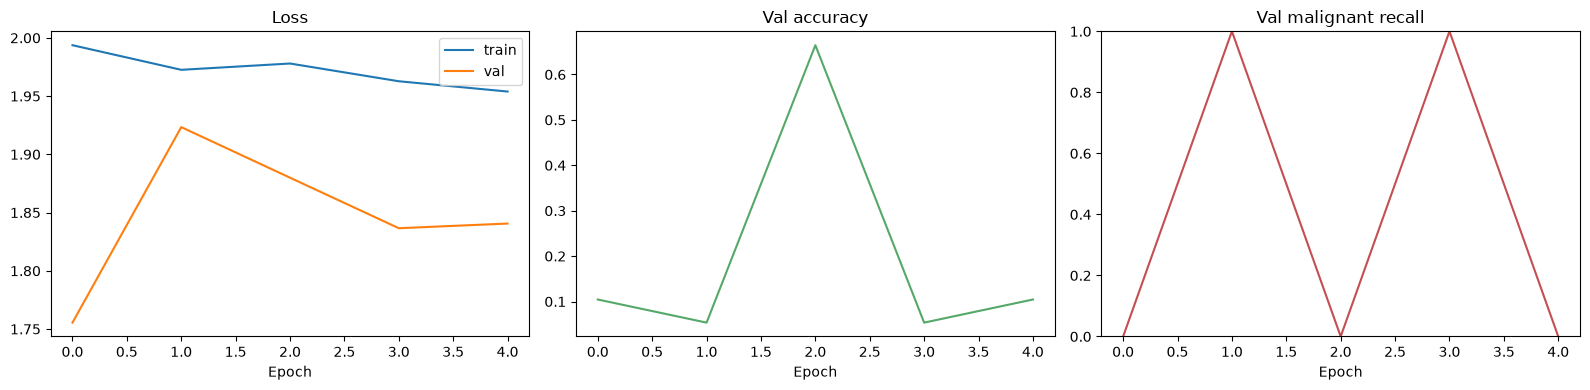

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_accuracy"], color="#55A868")
axes[1].set_title("Val accuracy")
axes[1].set_xlabel("Epoch")

axes[2].plot(history["malignant_recall"], color="#C44E52")
axes[2].set_title("Val malignant recall")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()


### Evaluate the best checkpoint

Reload the best-saved weights and evaluate -- confusion matrix and full per-class report, same as the baseline notebook.

In [7]:
model.load_state_dict(torch.load(CHAMPION_MODEL_PATH, map_location=device, weights_only=True))
val_loss, val_accuracy, val_preds, val_labels = evaluate(model, val_loader, criterion, device)

print(f"Best model — val_loss: {val_loss:.4f}  val_accuracy: {val_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(val_labels, val_preds, target_names=ALL_CLASSES))


Best model — val_loss: 1.7555  val_accuracy: 0.1044

Classification report:
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        53
         bcc       0.00      0.00      0.00        82
         bkl       0.10      1.00      0.19       160
          df       0.00      0.00      0.00        24
         mel       0.00      0.00      0.00       173
          nv       0.00      0.00      0.00      1018
        vasc       0.00      0.00      0.00        22

    accuracy                           0.10      1532
   macro avg       0.01      0.14      0.03      1532
weighted avg       0.01      0.10      0.02      1532



d:\Important\00-Projects\SafeDerm\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Important\00-Projects\SafeDerm\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Important\00-Projects\SafeDerm\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

### Confusion matrix

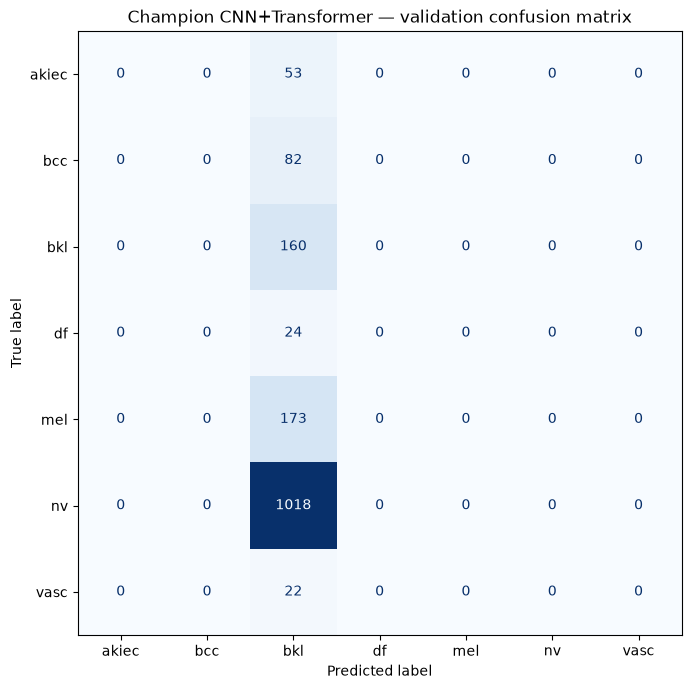

In [8]:
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=ALL_CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Champion CNN+Transformer — validation confusion matrix")
plt.tight_layout()
plt.show()


### Recall on malignant -- the metric that actually matters

Same `engine.malignant_recall()` used in `06` -- this is the number that decides whether the champion architecture actually earns its extra complexity, not overall accuracy.

In [9]:
recall_stats = malignant_recall(val_preds, val_labels)

print(f"Malignant lesions in val set: {recall_stats['malignant_total']}")
print(f"Correctly flagged (recall)  : {recall_stats['malignant_recall']:.3f}")
print(f"Missed (false negatives)    : {recall_stats['malignant_missed']}")

champion_metrics = {
    "model_variant": "champion",
    "val_loss": val_loss,
    "val_accuracy": val_accuracy,
    "malignant_recall": recall_stats["malignant_recall"],
    "malignant_missed": recall_stats["malignant_missed"],
    "malignant_total": recall_stats["malignant_total"],
    "best_epoch": history["best_epoch"],
    "stopped_epoch": history["stopped_epoch"],
}
CHAMPION_METRICS_PATH.write_text(json.dumps(champion_metrics, indent=2))
print(f"\nSaved metrics summary to {CHAMPION_METRICS_PATH}")


Malignant lesions in val set: 308
Correctly flagged (recall)  : 0.000
Missed (false negatives)    : 308

Saved metrics summary to D:\Important\00-Projects\SafeDerm\models\champion_metrics.json


### Baseline vs. champion

Loads both saved metrics summaries and compares directly -- no eyeballing two notebooks side by side. If `baseline_metrics.json` doesn't exist yet, run `06_baseline_model.ipynb` first.

In [10]:
if not BASELINE_METRICS_PATH.exists():
    print(f"No baseline metrics found at {BASELINE_METRICS_PATH} -- run 06_baseline_model.ipynb first.")
else:
    baseline_metrics = json.loads(BASELINE_METRICS_PATH.read_text())

    import pandas as pd
    comparison = pd.DataFrame([baseline_metrics, champion_metrics]).set_index("model_variant")
    comparison = comparison[["val_loss", "val_accuracy", "malignant_recall", "malignant_missed", "malignant_total"]]
    display(comparison)

    recall_delta = champion_metrics["malignant_recall"] - baseline_metrics["malignant_recall"]
    verdict = "beats" if recall_delta > 0 else ("ties" if recall_delta == 0 else "does not beat")
    print(f"\nChampion {verdict} baseline on malignant recall ({recall_delta:+.3f}).")
    if recall_delta <= 0:
        print(
            "If this holds after real training (not just this scaffold), the extra complexity of the "
            "transformer head isn't earning its keep on this dataset -- worth reconsidering before "
            "building calibration/the API around it."
        )


,val_loss,val_accuracy,malignant_recall,malignant_missed,malignant_total
model_variant,,,,,
baseline,0.643698,0.781332,0.730519,83,308
champion,1.755506,0.104439,0.000000,308,308



Champion does not beat baseline on malignant recall (-0.731).
If this holds after real training (not just this scaffold), the extra complexity of the transformer head isn't earning its keep on this dataset -- worth reconsidering before building calibration/the API around it.


### Summary

- CNN+Transformer champion model trained under the identical recipe as the baseline (ADR-006), best checkpoint saved to `models/champion_transformer.pt`.
- Direct comparison against the baseline on malignant recall above -- the deciding metric, not overall accuracy.
- `transformer_head` includes a real `nn.Dropout` layer -- required for `08_calibration_conformal.ipynb`'s MC Dropout uncertainty estimation, which the plain baseline architecture can't support (see `src/model.py`'s `_TransformerHead` docstring).
- `attention_rollout()` on the trained model (see `src/model.py`) gives a literal "where did the model look" map from the CLS token's attention over the 49 spatial patches -- worth a qualitative look here on a few validation images before moving to calibration, since it's part of ADR-002's stated case for this architecture over a plain CNN.
- No calibration yet -- that's still `08_calibration_conformal.ipynb`'s job, same as for the baseline.